### tidy up

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('../words.txt', 'r').read().splitlines()
words[:8]

['abakus',
 'abandon',
 'abazja',
 'abażur',
 'abażurek',
 'abdukcja',
 'abduktor',
 'abdykacja']

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [5]:
block_size = 3  # context size

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [6]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([400292, 3]) torch.Size([400292])
torch.Size([50134, 3]) torch.Size([50134])
torch.Size([50015, 3]) torch.Size([50015])


In [7]:
for x, y in zip(X_train[:20], Y_train[:20]):
    print(''.join(itos[ix.item()] for ix in x), '--->', itos[y.item()])

... ---> e
..e ---> n
.en ---> d
end ---> o
ndo ---> p
dop ---> r
opr ---> o
pro ---> t
rot ---> e
ote ---> z
tez ---> a
eza ---> .
... ---> n
..n ---> i
.ni ---> e
nie ---> k
iek ---> t
ekt ---> ó
któ ---> r
tór ---> y


In [8]:
X_train.shape

torch.Size([400292, 3])

In [9]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        # out variation = in variation
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)     # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [10]:
torch.manual_seed(42)

In [11]:
n_emb = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_emb), generator=g)
layers = [
    Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

13574


In [12]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.5184
  10000/ 300000: 1.4493
  20000/ 300000: 2.4856
  30000/ 300000: 2.3572
  40000/ 300000: 1.8950
  50000/ 300000: 1.9659
  60000/ 300000: 2.0029
  70000/ 300000: 1.9062
  80000/ 300000: 2.3208
  90000/ 300000: 2.1226
 100000/ 300000: 2.0482
 110000/ 300000: 2.2857
 120000/ 300000: 2.0345
 130000/ 300000: 2.0447
 140000/ 300000: 1.5883
 150000/ 300000: 1.9439
 160000/ 300000: 2.0900
 170000/ 300000: 2.1284
 180000/ 300000: 1.9861
 190000/ 300000: 2.2045
 200000/ 300000: 2.3177
 210000/ 300000: 2.1571
 220000/ 300000: 1.9186
 230000/ 300000: 1.3561
 240000/ 300000: 1.6950
 250000/ 300000: 1.7066
 260000/ 300000: 1.9045
 270000/ 300000: 1.9669
 280000/ 300000: 2.3873
 290000/ 300000: 1.8774


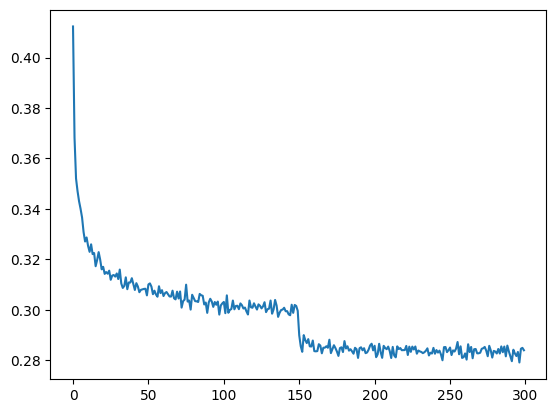

In [14]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [15]:
for layer in layers:
    layer.training = False

In [16]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, Y_train),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test),
    }[split]

    emb = C[x]      # (N, block_size, n_emb)
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8988488912582397
val 1.9151042699813843


In [17]:
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

cydieprożenie.
rozmłos.
powanie.
zamek.
głość.
jarka.
naszrość.
autulegryzowanie.
enie.
mia.
waatywanie.
sęknięcie.
jasienie.
podek.
peopomattarzedrątka.
pienie.
ple.
szanie.
mlużeden.
ziel.


### Embedding, Flatten and Sequential classes

In [54]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        # out variation = in variation
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)     # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    

class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [55]:
torch.manual_seed(42);

In [56]:
n_emb = 10
n_hidden = 200

model = Sequential([
    Embedding(vocab_size, n_emb),
    Flatten(),
    Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

13574


In [57]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.7862
  10000/ 300000: 2.2098
  20000/ 300000: 1.7995
  30000/ 300000: 1.8248
  40000/ 300000: 2.3025
  50000/ 300000: 2.0684
  60000/ 300000: 2.0065
  70000/ 300000: 1.9211
  80000/ 300000: 1.9571
  90000/ 300000: 2.0693
 100000/ 300000: 1.8738
 110000/ 300000: 2.0420
 120000/ 300000: 2.3460
 130000/ 300000: 1.8330
 140000/ 300000: 1.5794
 150000/ 300000: 2.0511
 160000/ 300000: 1.8621
 170000/ 300000: 2.1124
 180000/ 300000: 2.0868
 190000/ 300000: 1.3668
 200000/ 300000: 1.9500
 210000/ 300000: 2.0310
 220000/ 300000: 1.5401
 230000/ 300000: 1.6907
 240000/ 300000: 1.9046
 250000/ 300000: 2.0031
 260000/ 300000: 2.5130
 270000/ 300000: 1.8940
 280000/ 300000: 1.9771
 290000/ 300000: 1.8716


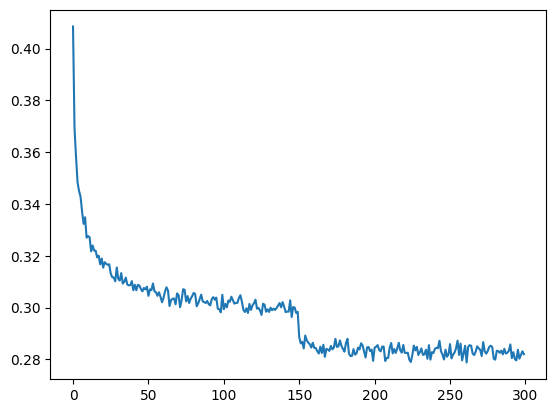

In [58]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

^ the stair is learning rate decay

In [59]:
for layer in model.layers:
    layer.training = False

In [60]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, Y_train),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8987776041030884
val 1.9186145067214966


In [61]:
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

cydź.
prożenie.
rozm.
kompleśnie.
pamek.
głość.
jarka.
naszrodło.
przenie.
jenieżek.
biofilipotaisanie.
asękuboteizjonizm.
koperek.
peopomatywanie.
ąszka.
imuzjoni.
zlerstwo.
luda.
egłos.
gram.
